# 📊 استكشاف بيانات أمراض القلب (Heart Disease Dataset)

هذه البيانات مستخرجة من **مستودع UCI للتعلم الآلي** (متوفرة أيضاً على منصة Kaggle). الهدف من المشروع هو بناء نموذج تصنيف (Classification Model) يتنبأ بمدى عرضة الشخص للإصابة بمرض في القلب بناءً على نتائج تحاليله وفحوصاته الحيوية.

* **عدد العينات (الصفوف):** 303 مريض.
* **عدد الخصائص (الأعمدة):** 14 عموداً (13 ميزة مستقلة + 1 المتغير المستهدف).

---

## 🗂️ قاموس البيانات (Data Dictionary)
لفهم البيانات بشكل صحيح قبل البدء في التحليل، إليك وصف تفصيلي لكل ميزة:

| اسم العمود (Feature) | الوصف (Description) | نوع البيانات |
| :--- | :--- | :--- |
| **age** | عمر المريض بالسنوات | رقمي (Numeric) |
| **sex** | الجنس (1 = ذكر، 0 = أنثى) | فئوي (Categorical) |
| **cp** | نوع ألم الصدر (0 إلى 3) | فئوي (Categorical) |
| **trestbps** | ضغط الدم أثناء الراحة (mm Hg) | رقمي (Numeric) |
| **chol** | نسبة الكوليسترول في الدم (mg/dl) | رقمي (Numeric) |
| **fbs** | سكر الدم صائماً (1 = أعلى من 120 mg/dl، 0 = أقل) | فئوي (Categorical) |
| **restecg** | نتائج تخطيط كهربية القلب أثناء الراحة (0 إلى 2) | فئوي (Categorical) |
| **thalach** | أقصى معدل لضربات القلب تم الوصول إليه | رقمي (Numeric) |
| **exang** | ذبحة صدرية ناتجة عن مجهود (1 = نعم، 0 = لا) | فئوي (Categorical) |
| **oldpeak** | انخفاض ST الناتج عن المجهود مقارنة بالراحة | رقمي (Numeric) |
| **slope** | ميل شريحة ST أثناء المجهود الأقصى | فئوي (Categorical) |
| **ca** | عدد الأوعية الدموية الرئيسية الملونة بالفلوروسكوبي (0-3) | رقمي (Numeric) |
| **thal** | نتيجة فحص الثاليوم (1 = طبيعي، 2 = خلل ثابت، 3 = خلل قابل للانعكاس) | فئوي (Categorical) |
| **target 🎯** | **النتيجة النهائية: (1 = معرض للإصابة، 0 = سليم)** | فئوي (Target) |

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [192]:
data='heart_disease_cleveland.csv'
heart_df=pd.read_csv(data)
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [193]:
heart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [194]:
heart_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [195]:
heart_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [196]:
heart_df.dropna(inplace=True)
heart_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<Figure size 1200x800 with 0 Axes>

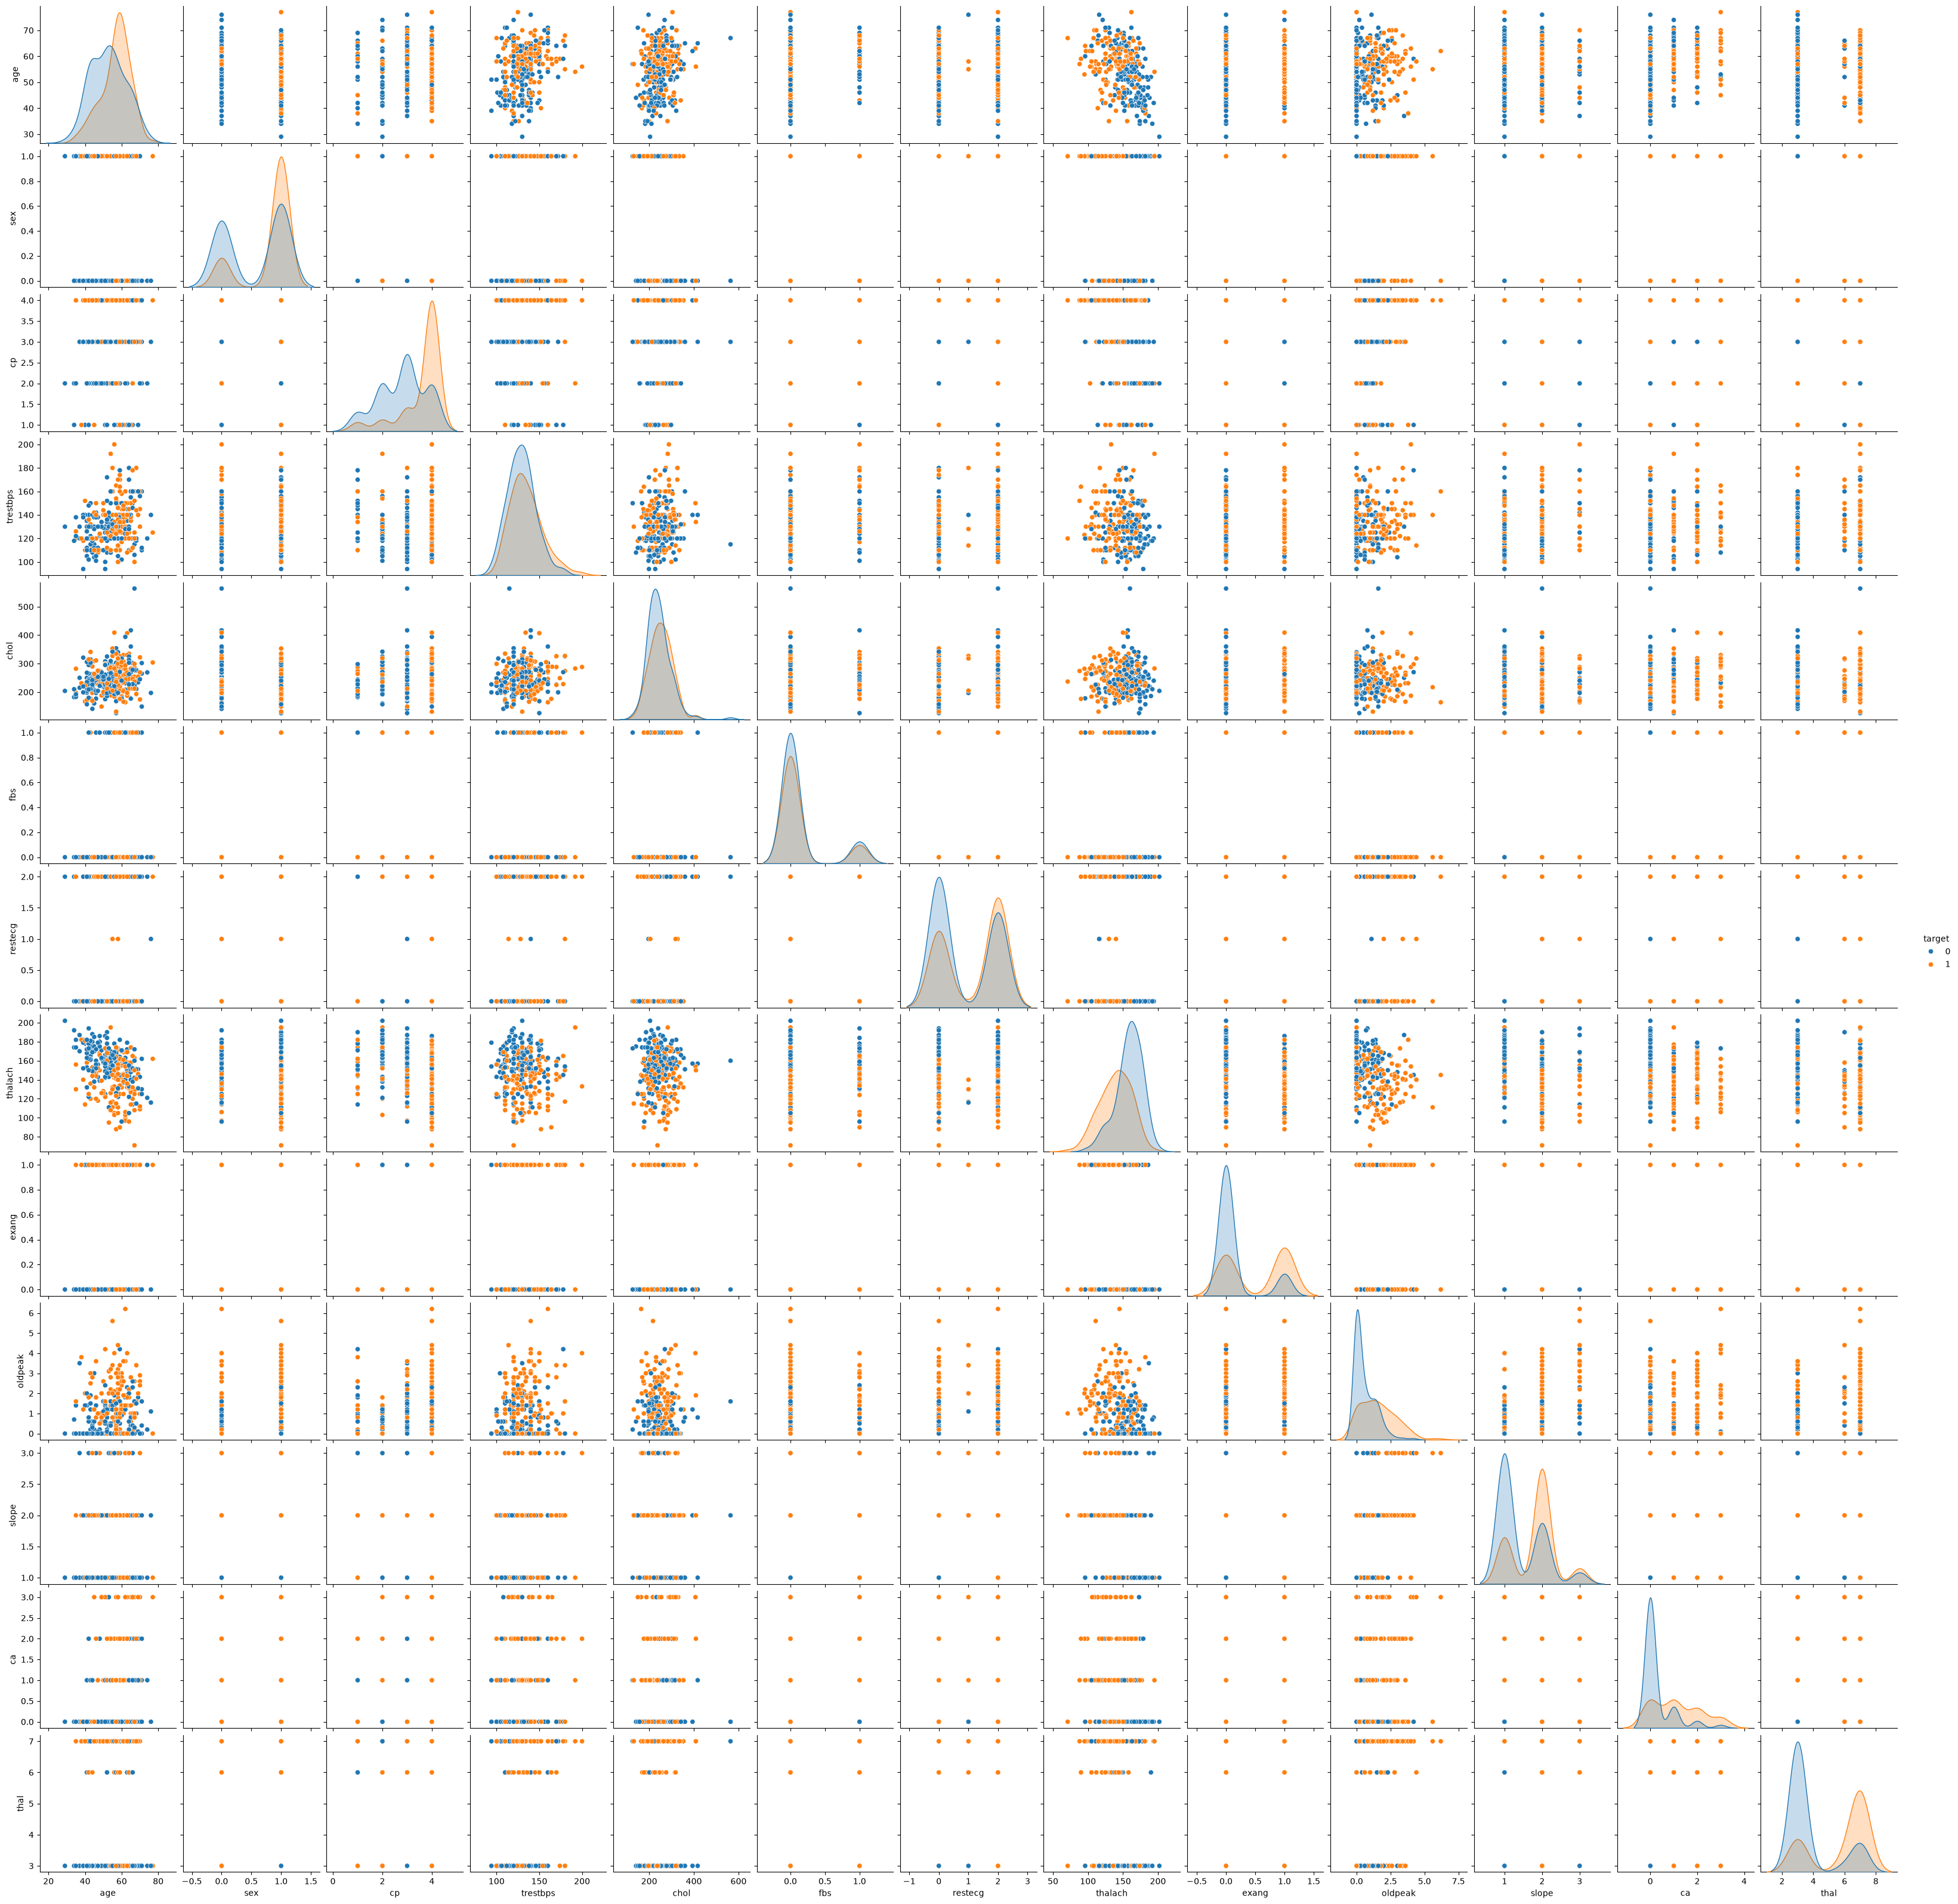

In [197]:
plt.figure(figsize=(12, 8))
sns.pairplot(heart_df, hue='target')

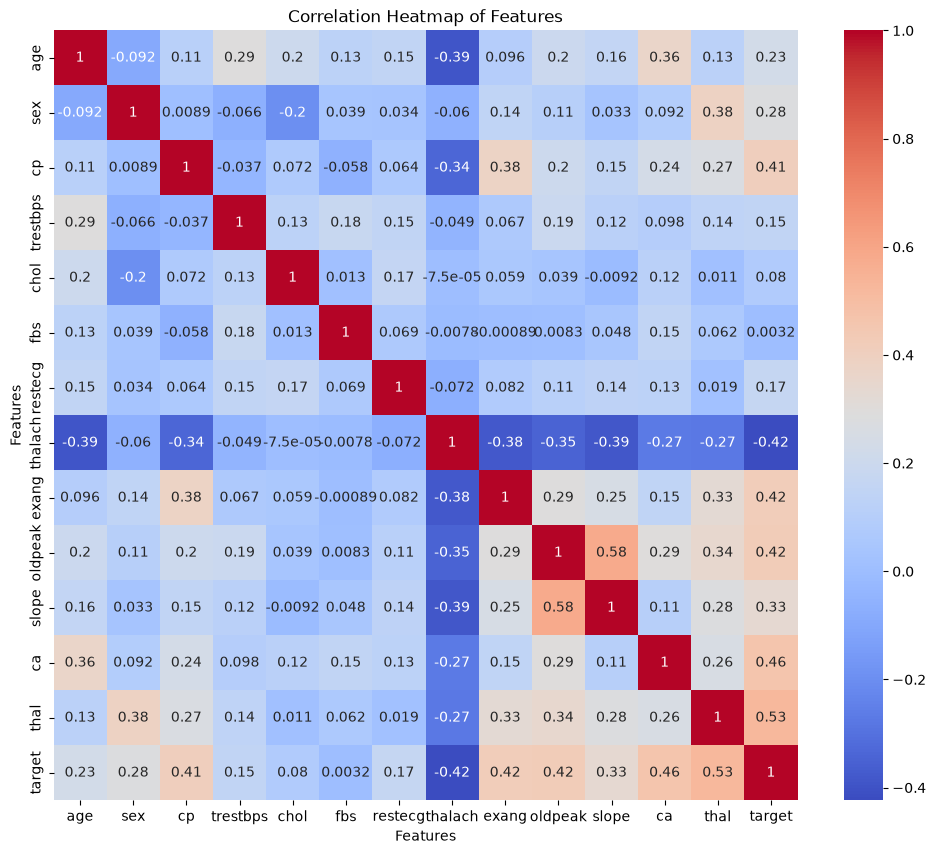

In [198]:
plt.figure(figsize=(12, 10))
sns.heatmap(heart_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

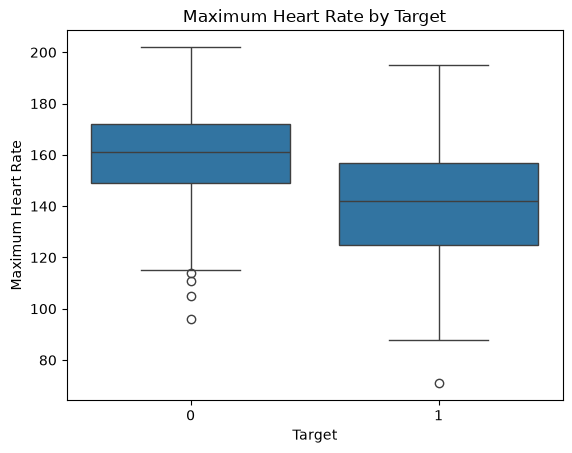

In [199]:
sns.boxplot(x='target', y='thalach', data=heart_df)
plt.title('Maximum Heart Rate by Target')
plt.xlabel('Target')
plt.ylabel('Maximum Heart Rate')
plt.show()

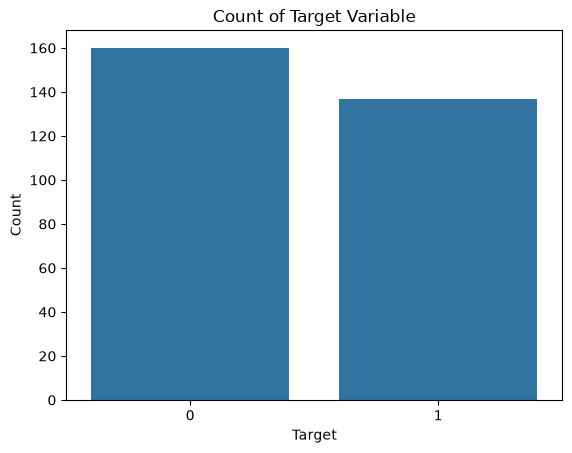

In [200]:
sns.countplot(x='target', data=heart_df)
plt.title('Count of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count') 
plt.show()

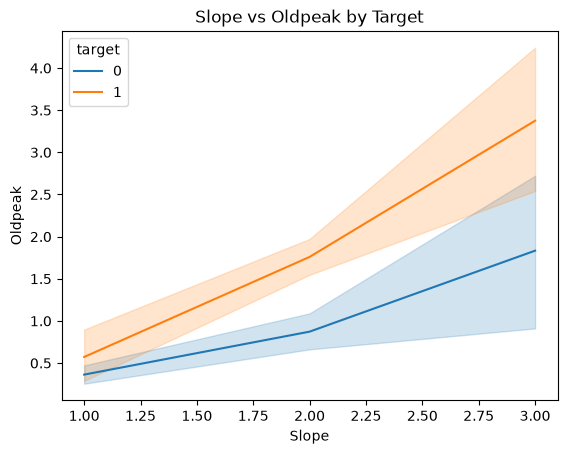

In [201]:
sns.lineplot(x='slope', y='oldpeak', hue='target', data=heart_df)
plt.title('Slope vs Oldpeak by Target')
plt.xlabel('Slope') 
plt.ylabel('Oldpeak')
plt.show()

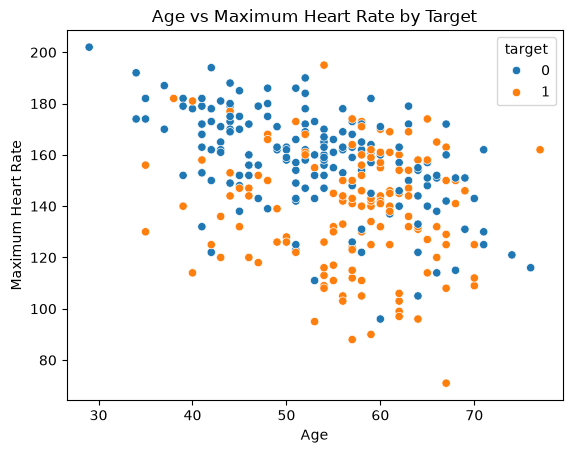

In [202]:
sns.scatterplot(x='age', y='thalach', hue='target', data=heart_df)
plt.title('Age vs Maximum Heart Rate by Target')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')
plt.show()

In [203]:
x=heart_df.drop('target', axis=1)
y=heart_df['target']
scaler=StandardScaler()
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.18, random_state=42)




In [204]:
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [205]:
model=LogisticRegression(max_iter=2000 , solver='liblinear', random_state=42)
model.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [206]:
y_pred=model.predict(X_test_scaled)

In [207]:
model_confusion=confusion_matrix(y_test, y_pred)
model_accuracy=accuracy_score(y_test, y_pred)
model_classification_report=classification_report(y_test, y_pred)

In [208]:
print("Confusion Matrix:\n", model_confusion)
print("\nAccuracy Score:", model_accuracy)
print("\nClassification Report:\n", model_classification_report)

Confusion Matrix:
 [[31  2]
 [ 4 17]]

Accuracy Score: 0.8888888888888888

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91        33
           1       0.89      0.81      0.85        21

    accuracy                           0.89        54
   macro avg       0.89      0.87      0.88        54
weighted avg       0.89      0.89      0.89        54



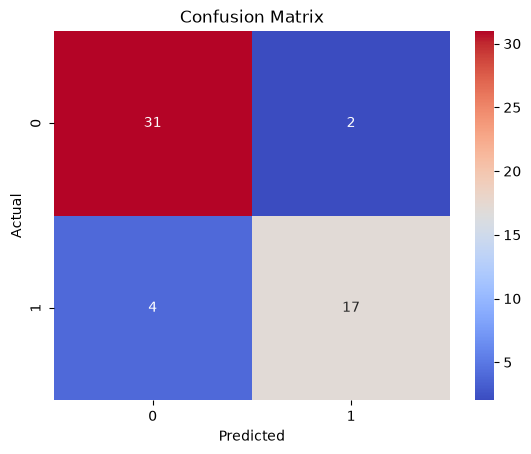

In [209]:
sns.heatmap(model_confusion, annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')    
plt.show()

In [210]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
rf_model.fit(x_train, y_train)
rf_y_pred = rf_model.predict(x_test)


print("Random Forest Accuracy:", accuracy_score(y_test, rf_y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_y_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_y_pred))


Random Forest Accuracy: 0.8703703703703703

Confusion Matrix:
 [[29  4]
 [ 3 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.82      0.86      0.84        21

    accuracy                           0.87        54
   macro avg       0.86      0.87      0.86        54
weighted avg       0.87      0.87      0.87        54



In [211]:
log_acc = accuracy_score(y_test, y_pred) 
rf_acc = accuracy_score(y_test, rf_y_pred)

print(f"Logistic Regression Accuracy: {log_acc * 100:.2f}%")
print(f"Random Forest Accuracy:       {rf_acc * 100:.2f}%")

Logistic Regression Accuracy: 88.89%
Random Forest Accuracy:       87.04%
